# EDA

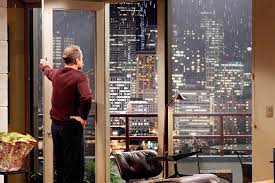

In [57]:
# module impot
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [ ]:
# Opening data and first overview of the raw data

df_initial = pd.read_csv("data/eda.csv")

df_initial["date"] = pd.to_datetime(df_initial["date"])

df = (df_initial.sort_values("date").drop_duplicates(subset="id", keep="last"))

print("=== Columns in eda.csv ===")
print(df_initial.columns)

print("\n=== Info about the dataset ===")
print(df_initial.info())
#df.info().to_csv("info.txt", sep="\t", index=False)

print("\n=== First 5 rows ===")
print(df_initial.head())

print("\n=== Summary statistics ===")
print(df_initial.describe())

In [ ]:
# Year of rennovation has some strange values
df_initial['yr_renovated'] = (df_initial['yr_renovated'] / 10)
df_initial['price_per_living_area'] = df_initial['price']/df_initial['sqft_living']
#print(df['yr_renovated'].unique())
#df_initial['price_per_living_area'].describe()

In [ ]:
# Number of duplicates 
print("Number of duplicate rows:", df_initial.duplicated().sum()) # there is no duplicate


In [61]:
# The over all statistics for of the not continuous data 
sanity_check_cols = ['zipcode','bedrooms', 'bathrooms', 'floors', 'waterfront', 'view','condition', 'grade',
                    'yr_built', 'yr_renovated', 'date']
output_lines_sanity = []
for col in sanity_check_cols:
    # Missing values
    missing = df_initial[col].isna().sum()
    if missing > 0:
        output_lines_sanity.append(f"Missing values in {col}\t{missing}")
    
    uniques = df_initial[col].unique()
    output_lines_sanity.append(f"\nUnique values for {col}:")
    output_lines_sanity.append("\t" + ", ".join(map(str, uniques)))
with open("sanity_check_results.txt", "w") as f:
    for line in output_lines_sanity:
        f.write(line + "\n")

# The over all statistics for of the not continuous data
continuous_cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
    'long', 'lat', 'sqft_living15', 'sqft_lot15', 'price']
percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]

results_continuos_var = []

for col in continuous_cols:
    # Missing values
    missing = df_initial[col].isna().sum()
    if missing > 0:
        results_continuos_var.append(f"Missing values in {col}\t{missing}")

    desc = df_initial[col].quantile([p/100 for p in percentiles])
    results_continuos_var.append(f"\n--- {col} ---")

    for p in percentiles:
        results_continuos_var.append(f"{p}th percentile\t{desc[p/100]}")

with open("Continous_var_results.txt", "w") as f:
    for line in results_continuos_var:
        f.write(line + "\n")

In [ ]:
# to check if unusual data & missing values
sanity_check_cols = ['bedrooms', 'bathrooms', 'floors','waterfront', 'view', 'condition', 'grade','yr_built', 'yr_renovated','date']
for col in df_initial.columns:
    if df_initial[col].isna().sum() > 0.0 :
        print(f"Missing values in {col}", df_initial[col].isna().sum()) # checking missing value
    if col in sanity_check_cols:
        print(f"\n unique values for {df_initial[col]}\n")
        print(df_initial[col].unique())

# to plot missing
msno.bar(df_initial)

In [ ]:
# Count listings per ZIP
zip_counts = df['zipcode'].value_counts().sort_index()

# Price per room
#df["price_per_room"] = df["price"] / df["bedrooms"]
df['price_per_living_area'] = df['price']/df['sqft_living']

# Average price per room per ZIP (sorted)
zip_price_area = df.groupby("zipcode")["price_per_living_area"].mean().sort_values()
mean_val = zip_price_area.mean()
std_val = zip_price_area.std()

# Compute city center (mean of coordinates)
city_center_lon = df["long"].mean()
city_center_lat = df["lat"].mean()

# Compute ZIP center coordinates
zip_centers = df.groupby("zipcode")[["long", "lat"]].mean()

# Convert degrees to km (approx for Seattle)
lat_km = 111
lon_km = 75

# Distance to city center
zip_centers["distance_to_center_km"] = (
    ((zip_centers["long"] - city_center_lon) * lon_km)**2 +
    ((zip_centers["lat"] - city_center_lat) * lat_km)**2
)**0.5

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

# Distance bins
bins = [0, 3, 6, 10, 15, 20, 30, 45]

# Colors for each distance bin
bin_colors = [
    "#084594",  # 0–3 km   dark blue
    "#2171B5",  # 3–6 km   blue
    "#6BAED6",  # 6–10 km  light blue
    "#F4A582",  # 10–15 km light red/orange
    "#D6604D",  # 15–20 km red
    "#B2182B",  # 20–30 km dark red
    "#67001F",  # 30–45 km very dark red
]

# Create discrete colormap
cmap = ListedColormap(bin_colors)

# Normalize according to the distance bins
norm = BoundaryNorm(bins, cmap.N)

# Get a color for each zipcode based on its distance
distances = zip_centers.loc[zip_price_area.index, "distance_to_center_km"]
colors = cmap(norm(distances))

# Create figure and axes
fig, ax = plt.subplots(figsize=(25, 6))

# Plot
zip_price_area.plot(kind="bar",color=colors,ax=ax)

# Reference lines
ax.axhline(mean_val,color="black",linestyle="--",label="Mean")

ax.axhline(mean_val + std_val,color="blue",linestyle="--",label="Mean + 1 Std")

ax.axhline(mean_val - std_val,color="blue",linestyle="--",label="Mean - 1 Std")

# Labels
ax.set_xlabel("Zipcode", fontsize=14)
ax.set_ylabel("Average Price per Area",fontsize=14)
ax.set_title(
    "Average Price per Area (Distance Bins Colored)"
)

ax.tick_params(axis="x", labelsize=12, rotation = 90)
ax.tick_params(axis="y", labelsize=12)
# Legend
ax.legend()

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    boundaries=bins,
    ticks=bins, pad= 0.01
)

cbar.set_label("Distance from Center (km)", fontsize=14)
plt.savefig("./Figure/Fig2_AvgPriceArea_district.png",dpi=100,format="png",bbox_inches="tight")
plt.show()

In [66]:
# Align distances with sorted price order
distances = zip_centers.loc[zip_price_area.index, "distance_to_center_km"]

# Condition 1: price per area within one std of the mean
cond_price = (zip_price_area >= mean_val - std_val) & (zip_price_area <= mean_val + std_val)

# Condition 2: distance < 10 km
cond_distance = distances < 10

# Combined condition
selected_zips = zip_price_area.index[cond_price & cond_distance]
selected_zips

Index([98178, 98059, 98056, 98108, 98118, 98007, 98006, 98008, 98144, 98005], dtype='int64', name='zipcode')

In [ ]:
# Filter to selected ZIP codes
selected_df = df[df["zipcode"].isin(selected_zips)]
#converting price to tousands $
selected_df["price"] = selected_df["price"] / 1000

variables = ["sqft_living", "price", "grade", "yr_built"]
labels = ["house area (foot square)", "price (tousand $)", "grade", 
          "yr of Construction"]

import matplotlib.pyplot as plt
import seaborn as sns

# Global style improvements
sns.set_theme(style="whitegrid")  # adds gridlines automatically

plt.rcParams["axes.labelsize"] = 18
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

plt.figure(figsize=(22, 26))

# Fancy color palette
palette = sns.color_palette("Set2")  # soft, professional colors

for i, (var, label) in enumerate(zip(variables, labels), 1):
    plt.subplot(3, 2, i)
    
    sns.boxplot(
        data=selected_df,
        x="zipcode",
        y=var,
        showfliers=False,        # hide outliers
        linewidth=2.2,           # thicker lines
        width=0.6,
        palette=palette          # fancy colors
    )
    
    plt.title(f"Distribution of {label} across selected ZIP codes", fontsize=22, pad=15)
    plt.xlabel("ZIP Code", fontsize=18)
    plt.ylabel(label, fontsize=18)
    plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("./Figure/Fig3_Dist_diffVar_selDist.png",dpi=100,format="png",bbox_inches="tight")
plt.show()



In [ ]:
# Filter to selected ZIP codes
selected_df = df[df["zipcode"].isin(selected_zips)].copy()

sns.set_theme(style="whitegrid")

plt.rcParams["axes.labelsize"] = 18
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

plt.figure(figsize=(18, 10))

# Fancy color palette
palette = sns.color_palette("Set2")

# Count of cases per ZIP
ax = sns.countplot(
    data=selected_df,
    x="zipcode",
    palette=palette
)

plt.title("Number of available cases per selected ZIP code", fontsize=22, pad=15)
plt.xlabel("ZIP Code", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.xticks(rotation=20)

# Compute waterfront counts per ZIP
waterfront_counts = selected_df.groupby("zipcode")["waterfront"].sum()

# Annotate each bar with waterfront count
for p in ax.patches:
    zip_code = p.get_x() + p.get_width() / 2
    height = p.get_height()
    zipcode_label = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    
    wf_count = waterfront_counts.get(int(zipcode_label), 0)
    
    ax.annotate(
        f"WF: {wf_count}",
        (zip_code, height),
        ha="center",
        va="bottom",
        fontsize=14,
        color="black",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.savefig("./Figure/Fig4_NumberHouse_selDist.png",dpi=100,format="png",bbox_inches="tight")
plt.show()


In [ ]:
# Filter to selected ZIP codes
selected_df = df[df["zipcode"].isin(selected_zips)].copy()

sns.set_theme(style="whitegrid")

# Adjusted, more balanced font sizes
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Larger single panel
plt.figure(figsize=(9, 5))

# Fancy color palette
palette = sns.color_palette("Set2")

# View countplot (single panel)
sns.countplot(
    data=selected_df,
    x="zipcode",
    hue="view",
    palette=palette
)

plt.title("View quality distribution across selected ZIP codes", fontsize=20, pad=15)
plt.xlabel("ZIP Code", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=20)

plt.legend(title="View Level", labels=["0", "1", "2", "3", "4"], fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("./Figure/Fig5_ViewQuality_selDist.png",dpi=100,format="png",bbox_inches="tight")
plt.show()


In [ ]:
# -----------------------------
# 1. Filter to selected ZIP codes
# -----------------------------
selected_df = df[df["zipcode"].isin(selected_zips)].copy()

# -----------------------------
# 2. Convert price to thousand dollars
# -----------------------------
selected_df["price_thousand"] = selected_df["price"] / 1000

# -----------------------------
# 3. Filter buildings ≤ 60 years old
# -----------------------------
current_year = 2026
selected_df = selected_df[selected_df["yr_built"] >= (current_year - 60)]

# -----------------------------
# 4. Select only 2, 3, 4 rooms
# -----------------------------
selected_df = selected_df[selected_df["bedrooms"].isin([2, 3, 4])]

# -----------------------------
# 5. Plot settings
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20

plt.figure(figsize=(20, 9))

# Custom colors for room categories
room_palette = {
    2: "#66c2a5",   # greenish
    3: "#fc8d62",   # orange
    4: "#8da0cb"    # bluish
}

# -----------------------------
# 6. Compute medians
# -----------------------------
med_2 = selected_df[selected_df["bedrooms"] == 2]["price_thousand"].median()
med_3 = selected_df[selected_df["bedrooms"] == 3]["price_thousand"].median()
med_4 = selected_df[selected_df["bedrooms"] == 4]["price_thousand"].median()

# -----------------------------
# 7. Draw median lines FIRST (background)
# -----------------------------
plt.axhline(med_2, color=room_palette[2], linestyle="--", linewidth=3, alpha=0.6)
plt.axhline(med_3, color=room_palette[3], linestyle="--", linewidth=3, alpha=0.6)
plt.axhline(med_4, color=room_palette[4], linestyle="--", linewidth=3, alpha=0.6)

# -----------------------------
# 8. Draw boxplot on top
# -----------------------------
ax = sns.boxplot(
    data=selected_df,
    x="zipcode",
    y="price_thousand",
    hue="bedrooms",
    palette=room_palette,
    showfliers=False,
    linewidth=2
)

plt.title("Price distribution for 2-, 3-, and 4-room units (≤ 60 years old)", fontsize=24, pad=20)
plt.xlabel("ZIP Code", fontsize=22)
plt.ylabel("Price (thousand $)", fontsize=22)
plt.xticks(rotation=20)

plt.legend(
    title="Rooms",
    fontsize=18,
    title_fontsize=22
)

# -----------------------------
# 9. Add labels for median lines (on top)
# -----------------------------
ax.text(len(selected_zips) - 0.3, med_2, f"Median 2 rooms: {med_2:.1f}",
        color=room_palette[2], fontsize=20, va="center")

ax.text(len(selected_zips) - 0.3, med_3, f"Median 3 rooms: {med_3:.1f}",
        color=room_palette[3], fontsize=20, va="center")

ax.text(len(selected_zips) - 0.3, med_4, f"Median 4 rooms: {med_4:.1f}",
        color=room_palette[4], fontsize=20, va="center")

plt.tight_layout()
plt.savefig("./Figure/Fig6_Price_one_two_three_rooms_selDist.png",dpi=100,format="png",bbox_inches="tight")
plt.show()


In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

districts = [
    "98108", "98118", "98144", "98178", "98056",
    "98059", "98005", "98006", "98007", "98008"
]

criteria = [
    "Distance (<10 km)",
    "Price per area",
    "Price stability",
    "Median price 2/3/4 rooms",
    "House area distribution",
    "Grade distribution",
    "Year of construction",
    "Number of cases",
    #"Waterfront influence",
    "View quality"
]

# ---------------------------------------------------------
# 1. Distinct 6-level color scale
# ---------------------------------------------------------
scores = np.array([
    [6, 6, 6, 5, 4, 4, 3, 3, 3, 3],  # Distance
    [5, 5, 5, 4, 4, 2, 2, 2, 2, 2],  # Price per area
    [5, 5, 5, 3, 3, 5, 5, 5, 1, 5],  # Price stability
    [5, 5, 5, 4, 4, 3, 3, 3, 3, 3],  # Median price
    [5, 5, 5, 4, 4, 6, 6, 6, 6, 6],  # House area
    [4, 4, 4, 4, 4, 6, 6, 6, 6, 6],  # Grade
    [4, 5, 5, 3, 3, 6, 6, 6, 6, 6],  # Construction year
    [5, 5, 5, 4, 4, 4, 4, 6, 1, 4],  # Number of cases
    #[6, 6, 6, 3, 3, 3, 6, 6, 5, 6],  # Waterfront
    [3, 3, 3, 3, 3, 5, 5, 5, 5, 5]   # View
])
colors = [
    "#d73027",  # 1 - Very poor
    "#f46d43",  # 2 - Poor
    "#fdae61",  # 3 - Fair
    "#a6d96a",  # 4 - Good
    "#66bd63",  # 5 - Very good
    "#1a9850"   # 6 - Excellent
]

cmap = ListedColormap(colors)

# Boundaries ensure that each integer score gets
# its own distinct color
bounds = np.arange(0.5, 6.5, 1)
norm = BoundaryNorm(bounds, cmap.N)


# ---------------------------------------------------------
# 2. Create heatmap
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 9))

heatmap = ax.imshow(scores,cmap=cmap,norm=norm,aspect="auto")

# ---------------------------------------------------------
# 3. X-axis
# ---------------------------------------------------------

ax.set_xticks(np.arange(len(districts)))

ax.set_xticklabels(
    districts,
    fontsize=13,
    fontweight="bold",
    rotation=20,
    ha="right"
)


# ---------------------------------------------------------
# 4. Y-axis
# ---------------------------------------------------------

ax.set_yticks(np.arange(len(criteria)))

ax.set_yticklabels(
    criteria,
    fontsize=12,
    fontweight="bold"
)


# ---------------------------------------------------------
# 5. Numbers inside cells
# ---------------------------------------------------------

for row in range(scores.shape[0]):
    for col in range(scores.shape[1]):

        ax.text(
            col,
            row,
            str(scores[row, col]),
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="black"
        )


# ---------------------------------------------------------
# 6. Cell borders
# ---------------------------------------------------------

ax.set_xticks(
    np.arange(-0.5, len(districts), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(criteria), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# ---------------------------------------------------------
# 7. Distinct colorbar
# ---------------------------------------------------------

cbar = fig.colorbar(
    heatmap,
    ax=ax,
    boundaries=bounds,
    ticks=np.arange(1, 7),
    fraction=0.035,
    pad=0.03
)

cbar.ax.set_yticklabels([
    "1 — Very poor",
    "2 — Poor",
    "3 — Fair",
    "4 — Good",
    "5 — Very good",
    "6 — Excellent"
])

cbar.ax.tick_params(
    labelsize=11
)

# Colorbar title
cbar.set_label(
    "Score",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)


# ---------------------------------------------------------
# 8. Title
# ---------------------------------------------------------

ax.set_title(
    "Rough District Assessment for Nicole",
    fontsize=20,
    fontweight="bold",
    pad=20
)


# ---------------------------------------------------------
# 9. Axis titles
# ---------------------------------------------------------

ax.set_xlabel(
    "District",
    fontsize=15,
    fontweight="bold",
    labelpad=15
)

ax.set_ylabel(
    "Evaluation criterion",
    fontsize=15,
    fontweight="bold",
    labelpad=15
)


# ---------------------------------------------------------
# 10. Improve tick appearance
# ---------------------------------------------------------

ax.tick_params(
    axis="x",
    labelsize=13,
    pad=5
)

ax.tick_params(
    axis="y",
    labelsize=13,
    pad=7
)


# ---------------------------------------------------------
# 11. Layout
# ---------------------------------------------------------

plt.tight_layout()
plt.savefig("./Figure/Fig7_Overall_evaluation.png", dpi=100,format="png")
plt.show()

In [112]:
## Candidate 2 rooms
candidate_2room = df[
    (df["zipcode"].isin([98108, 98118, 98144])) &
    (df["bedrooms"] == 2) &
    (df["price"].between(340000, 370000)) &
    (df["yr_built"] > 1990) &
    (df["grade"] >= 8)
][[
    "id",
    "zipcode",
    "bedrooms",
    "sqft_living",
    "price",
    "view",
    "grade",
    "yr_built",
    "yr_renovated",
    "waterfront",
    "date"
]].copy()

candidate_2room

,id,zipcode,bedrooms,sqft_living,price,view,grade,yr_built,yr_renovated,waterfront,date
21003,7548301056,98144,2.000,1340.000,345000.000,0.000,8,2008,0.000,0.000,2014-06-09
14032,1498300775,98144,2.000,930.000,355000.000,0.000,8,2007,0.000,0.000,2014-06-24
19933,7548301044,98144,2.000,1320.000,342500.000,0.000,8,2008,0.000,0.000,2014-07-10
20728,1604601572,98118,2.000,860.000,345000.000,0.000,9,2009,0.000,0.000,2014-09-05
1273,567000392,98144,2.000,920.000,363000.000,0.000,8,2009,0.000,0.000,2014-11-03
19909,6056111370,98108,2.000,1270.000,340000.000,0.000,8,2012,0.000,0.000,2014-11-24
17666,424049283,98144,2.000,830.000,345000.000,0.000,8,2009,0.000,0.000,2015-04-15


In [111]:
candidate_3room = df[
    (df["zipcode"].isin([98108, 98118, 98144])) &
    (df["bedrooms"] == 3) &
    (df["price"].between(440000, 470000)) &
    (df["yr_built"] > 1980) &
    (df["grade"] >= 8)
][[
    "id",
    "zipcode",
    "bedrooms",
    "sqft_living",
    "price",
    "view",
    "grade",
    "yr_built",
    "yr_renovated",
    "waterfront",
    "date"
]].copy()

candidate_3room

,id,zipcode,bedrooms,sqft_living,price,view,grade,yr_built,yr_renovated,waterfront,date
10214,6909200335,98144,3.000,1430.000,457500.000,0.000,8,1996,0.000,0.000,2014-06-24
476,1604602050,98118,3.000,1610.000,460000.000,2.000,9,2005,0.000,NaN,2014-07-11
19762,1498300875,98144,3.000,1550.000,445000.000,0.000,8,2006,0.000,0.000,2014-08-14
3894,567000268,98144,3.000,1639.000,450000.000,0.000,8,2003,NaN,0.000,2014-08-21
20232,9320350130,98108,3.000,2330.000,453000.000,0.000,9,2004,0.000,NaN,2014-08-23
21202,5700000446,98144,3.000,1590.000,465000.000,0.000,8,2014,0.000,0.000,2014-10-29
13908,2394600157,98144,3.000,1530.000,460000.000,0.000,8,2008,0.000,0.000,2015-04-07
5533,8944550050,98118,3.000,2080.000,448500.000,0.000,8,2010,NaN,0.000,2015-05-08
